
## Faster R-CNN

This notebook implements a **simplified Faster R-CNN-style pipeline** for educational purposes.

### Pipeline:
1. **Backbone CNN**: Extracts feature maps from the input image.
2. **Region Proposal Network (RPN)**: Slides over feature maps and proposes candidate regions (anchors).
3. **ROI Pooling**: Converts variable-sized regions into fixed-size feature maps.
4. **Detection Head**: Performs classification and bounding box regression.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: []


Train shape: (50000, 32, 32, 3)
Test  shape: (10000, 32, 32, 3)


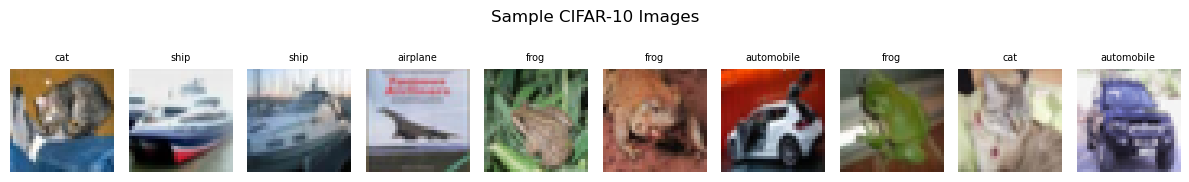

In [2]:
# Using CIFAR-10 (10 classes, color images 32x32) — more realistic than MNIST for detection
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test,  10)

print("Train shape:", x_train.shape)
print("Test  shape:", x_test.shape)

# Visualize sample images
plt.figure(figsize=(12, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_test[i])
    plt.title(CLASS_NAMES[y_test[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images", fontsize=12)
plt.tight_layout()
plt.show()


In [3]:
def build_backbone(input_shape=(32, 32, 3)):
    """
    Lightweight VGG-style backbone CNN.
    Returns feature maps — the shared base for RPN + detection head.
    """
    inputs = keras.Input(shape=input_shape, name="backbone_input")

    # Block 1
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='b1_conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu', name='b1_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='b1_pool')(x)   # 32→16

    # Block 2
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='b2_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu', name='b2_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2, name='b2_pool')(x)   # 16→8

    # Block 3
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='b3_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu', name='b3_conv2')(x)
    x = layers.BatchNormalization()(x)
    # Output feature map: (8, 8, 256)

    backbone = keras.Model(inputs, x, name="backbone")
    return backbone

backbone = build_backbone()
backbone.summary()
print(f"\n✅ Backbone output shape: {backbone.output_shape}")


Model: "backbone"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ backbone_input (InputLayer)          │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_conv1 (Conv2D)                    │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_conv2 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b1_pool (MaxPooling2D)               │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_conv1 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_conv2 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b2_pool (MaxPooling2D)               │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_conv1 (Conv2D)                    │ (None, 8, 8, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ b3_conv2 (Conv2D)                    │ (None, 8, 8, 256)           │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,148,992 (4.38 MB)

 Trainable params: 1,147,200 (4.38 MB)

 Non-trainable params: 1,792 (7.00 KB)


✅ Backbone output shape: (None, 8, 8, 256)


In [4]:
def generate_anchors(feature_map_h, feature_map_w,
                     original_h, original_w,
                     ratios=[0.5, 1.0, 2.0],
                     scales=[0.5, 1.0, 1.5]):
    """
    Generate anchor boxes for every position in the feature map.
    Each position gets len(ratios) x len(scales) = 9 anchors.
    Returns: (N, 4) array of [y1, x1, y2, x2] normalized to [0,1]
    """
    anchors = []
    for i in range(feature_map_h):
        for j in range(feature_map_w):
            # Center of this feature map cell in original image coords (normalized)
            cx = (j + 0.5) / feature_map_w
            cy = (i + 0.5) / feature_map_h

            for ratio in ratios:
                for scale in scales:
                    area = scale ** 2
                    w_a  = np.sqrt(area / ratio)
                    h_a  = w_a * ratio

                    x1 = cx - w_a / 2
                    y1 = cy - h_a / 2
                    x2 = cx + w_a / 2
                    y2 = cy + h_a / 2

                    # Clip to image bounds
                    x1, y1 = max(0, x1), max(0, y1)
                    x2, y2 = min(1, x2), min(1, y2)

                    anchors.append([y1, x1, y2, x2])

    anchors = np.array(anchors, dtype=np.float32)
    print(f"✅ Generated {len(anchors)} anchors for {feature_map_h}x{feature_map_w} feature map")
    return anchors

# Feature map from backbone is 8x8 for 32x32 input
anchors = generate_anchors(8, 8, 32, 32)
print(f"   Anchor array shape: {anchors.shape}")


✅ Generated 576 anchors for 8x8 feature map
   Anchor array shape: (576, 4)


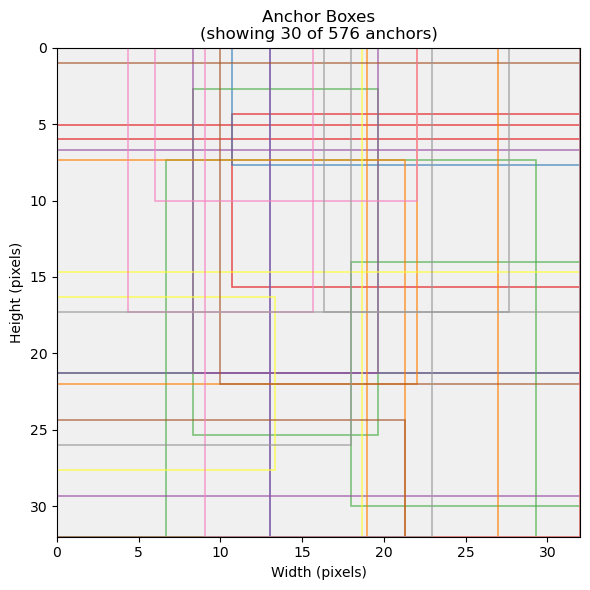

✅ Saved: anchors_visualization.png


In [5]:
def visualize_anchors(anchors, image_size=32, num_show=30, title="Anchor Boxes"):
    """Visualize a subset of anchors on a blank canvas."""
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.set_xlim(0, image_size)
    ax.set_ylim(image_size, 0)
    ax.set_facecolor('#f0f0f0')

    # Show sample anchors
    indices = np.random.choice(len(anchors), min(num_show, len(anchors)), replace=False)
    colors  = plt.cm.Set1(np.linspace(0, 1, num_show))

    for idx, color in zip(indices, colors):
        y1, x1, y2, x2 = anchors[idx] * image_size
        w = x2 - x1
        h = y2 - y1
        rect = patches.Rectangle((x1, y1), w, h,
                                   linewidth=1.2, edgecolor=color,
                                   facecolor='none', alpha=0.7)
        ax.add_patch(rect)

    ax.set_title(f"{title}\n(showing {num_show} of {len(anchors)} anchors)", fontsize=12)
    ax.set_xlabel("Width (pixels)")
    ax.set_ylabel("Height (pixels)")
    plt.tight_layout()
    plt.savefig("anchors_visualization.png", dpi=150)
    plt.show()
    print("✅ Saved: anchors_visualization.png")

visualize_anchors(anchors, image_size=32)


In [6]:
def build_rpn(feature_map_shape, num_anchors_per_pos=9):
    """
    RPN slides a small network over the feature map.
    For each anchor it predicts:
      - objectness score (object vs background)
      - 4 box deltas (dx, dy, dw, dh) for refinement
    """
    inputs = keras.Input(shape=feature_map_shape, name="rpn_input")

    # Shared conv layer (slides over feature map)
    shared = layers.Conv2D(256, 3, padding='same', activation='relu', name='rpn_shared')(inputs)

    # Objectness branch: is there an object in this anchor? (binary per anchor)
    objectness = layers.Conv2D(num_anchors_per_pos, 1, activation='sigmoid', name='rpn_objectness')(shared)
    objectness = layers.Reshape((-1, 1), name='rpn_obj_flat')(objectness)

    # Box regression branch: refine anchor coordinates
    box_deltas = layers.Conv2D(num_anchors_per_pos * 4, 1, activation='linear', name='rpn_box_deltas')(shared)
    box_deltas = layers.Reshape((-1, 4), name='rpn_box_flat')(box_deltas)

    rpn = keras.Model(inputs, [objectness, box_deltas], name="rpn")
    return rpn

# Feature map from backbone: (8, 8, 256)
rpn = build_rpn(feature_map_shape=(8, 8, 256), num_anchors_per_pos=9)
rpn.summary()


Model: "rpn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ rpn_input (InputLayer)        │ (None, 8, 8, 256)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rpn_shared (Conv2D)           │ (None, 8, 8, 256)         │         590,080 │ rpn_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rpn_objectness (Conv2D)       │ (None, 8, 8, 9)           │           2,313 │ rpn_shared[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rpn_box_deltas (Conv2D)       │ (None, 8, 8, 36)          │           9,252 │ rpn_shared[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rpn_obj_flat (Reshape)        │ (None, 576, 1)            │               0 │ rpn_objectness[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rpn_box_flat (Reshape)        │ (None, 576, 4)            │               0 │ rpn_box_deltas[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 601,645 (2.30 MB)

 Trainable params: 601,645 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class ROIPoolingLayer(layers.Layer):
    """
    Crops regions from the feature map based on proposed boxes,
    then resizes each crop to a fixed size (pool_h x pool_w).
    This ensures all ROIs have the same shape for the Dense head.
    """
    def __init__(self, pool_h=4, pool_w=4, **kwargs):
        super().__init__(**kwargs)
        self.pool_h = pool_h
        self.pool_w = pool_w

    def call(self, feature_map, boxes):
        """
        feature_map : (1, H, W, C)
        boxes       : (N, 4) normalized [y1, x1, y2, x2]
        Returns     : (N, pool_h, pool_w, C)
        """
        # tf.image.crop_and_resize needs box_indices (which image each box belongs to)
        num_boxes  = tf.shape(boxes)[0]
        box_indices = tf.zeros([num_boxes], dtype=tf.int32)  # all from image 0

        pooled = tf.image.crop_and_resize(
            image      = feature_map,         # (1, H, W, C)
            boxes      = boxes,               # (N, 4)
            box_indices= box_indices,
            crop_size  = [self.pool_h, self.pool_w]
        )
        return pooled  # (N, pool_h, pool_w, C)

    def get_config(self):
        config = super().get_config()
        config.update({"pool_h": self.pool_h, "pool_w": self.pool_w})
        return config

print("✅ ROIPoolingLayer defined")


✅ ROIPoolingLayer defined


In [8]:
def build_detection_head(num_classes=10, roi_shape=(4, 4, 256)):
    """
    Takes pooled ROI features and outputs:
      - class probabilities (softmax over num_classes)
      - bounding box refinements (4 values per class)
    """
    inputs = keras.Input(shape=roi_shape, name="roi_input")

    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Classification
    cls_output = layers.Dense(num_classes, activation='softmax', name='class_output')(x)

    # Box regression (4 deltas per class)
    box_output = layers.Dense(num_classes * 4, activation='linear', name='box_output')(x)

    head = keras.Model(inputs, [cls_output, box_output], name="detection_head")
    return head

detection_head = build_detection_head(num_classes=10)
detection_head.summary()


Model: "detection_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ roi_input (InputLayer)        │ (None, 4, 4, 256)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 4096)              │               0 │ roi_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 512)               │       2,097,664 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 512)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │         131,328 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 256)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ class_output (Dense)          │ (None, 10)                │           2,570 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ box_output (Dense)            │ (None, 40)                │          10,280 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,241,842 (8.55 MB)

 Trainable params: 2,241,842 (8.55 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
def run_detection_pipeline(image, backbone, rpn, detection_head,
                            anchors, top_k=10, obj_threshold=0.5):
    """
    End-to-end inference pipeline:
    image → backbone → RPN → top proposals → ROI pooling → head → boxes + classes
    """
    img_input = np.expand_dims(image, 0)  # (1, H, W, C)

    # Step 1: Extract feature map
    feature_map = backbone(img_input, training=False)   # (1, 8, 8, 256)

    # Step 2: RPN — get objectness scores + box deltas
    objectness, box_deltas = rpn(feature_map, training=False)
    obj_scores = objectness[0, :, 0].numpy()            # (N_anchors,)

    # Step 3: Select top-K proposals by objectness score
    top_indices = np.argsort(obj_scores)[::-1][:top_k]
    proposals   = anchors[top_indices]                  # (top_k, 4)

    print(f"\n📦 RPN selected {len(proposals)} proposals")
    print(f"   Top objectness scores: {obj_scores[top_indices[:5]].round(3)}")

    # Step 4: ROI Pooling
    roi_layer = ROIPoolingLayer(pool_h=4, pool_w=4)
    pooled    = roi_layer(feature_map, tf.constant(proposals))  # (top_k, 4, 4, 256)

    # Step 5: Detection head
    cls_probs, box_preds = detection_head(pooled, training=False)

    # Step 6: Get predicted class per proposal
    pred_classes = np.argmax(cls_probs.numpy(), axis=1)
    pred_scores  = np.max(cls_probs.numpy(), axis=1)

    return proposals, pred_classes, pred_scores, obj_scores[top_indices]

# Test on a sample image
sample_img  = x_test[5]
proposals, pred_classes, pred_scores, obj_scores = run_detection_pipeline(
    sample_img, backbone, rpn, detection_head, anchors
)

print(f"\n🎯 Predictions:")
for i, (cls, score) in enumerate(zip(pred_classes, pred_scores)):
    print(f"   Proposal {i+1}: Class={CLASS_NAMES[cls]:<12} Confidence={score:.3f}")



📦 RPN selected 10 proposals
   Top objectness scores: [0.506 0.505 0.505 0.505 0.505]

🎯 Predictions:
   Proposal 1: Class=frog         Confidence=0.102
   Proposal 2: Class=frog         Confidence=0.102
   Proposal 3: Class=truck        Confidence=0.101
   Proposal 4: Class=frog         Confidence=0.101
   Proposal 5: Class=truck        Confidence=0.101
   Proposal 6: Class=deer         Confidence=0.101
   Proposal 7: Class=frog         Confidence=0.102
   Proposal 8: Class=frog         Confidence=0.101
   Proposal 9: Class=frog         Confidence=0.101
   Proposal 10: Class=frog         Confidence=0.102


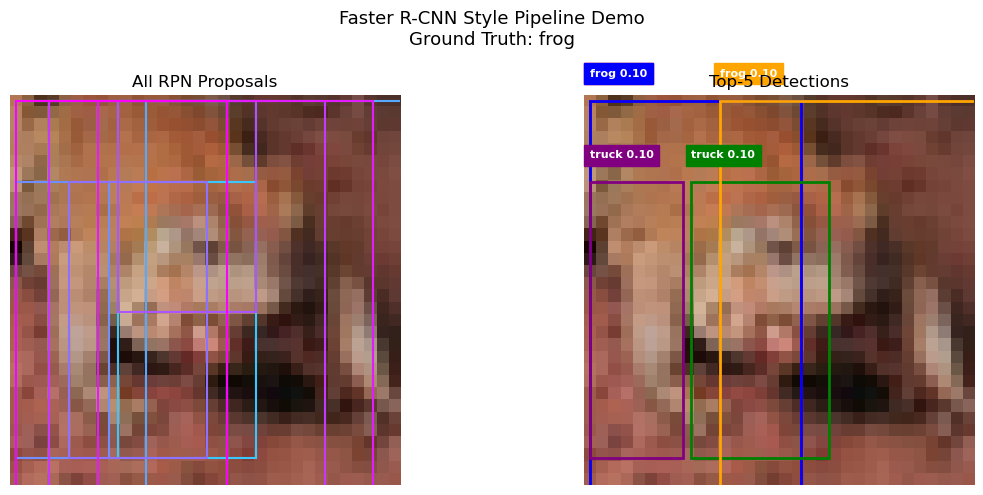

✅ Saved: detection_output.png


In [10]:
def visualize_detections(image, proposals, pred_classes, pred_scores,
                          obj_scores, class_names, top_n=5, title="Detection Output"):
    """Draw top-N proposal boxes with predicted class labels on the image."""

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    H, W = image.shape[:2]

    # --- Left: all proposals ---
    axes[0].imshow(image)
    axes[0].set_title("All RPN Proposals", fontsize=12)
    cmap = plt.cm.cool(np.linspace(0, 1, len(proposals)))
    for idx, (box, color) in enumerate(zip(proposals, cmap)):
        y1, x1, y2, x2 = box * np.array([H, W, H, W])
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=1.5, edgecolor=color, facecolor='none')
        axes[0].add_patch(rect)
    axes[0].axis('off')

    # --- Right: top-N detections with labels ---
    axes[1].imshow(image)
    axes[1].set_title(f"Top-{top_n} Detections", fontsize=12)
    colors = ['red','blue','green','orange','purple']

    for i in range(min(top_n, len(proposals))):
        y1, x1, y2, x2 = proposals[i] * np.array([H, W, H, W])
        color = colors[i % len(colors)]
        rect  = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                    linewidth=2, edgecolor=color, facecolor='none')
        axes[1].add_patch(rect)
        label = f"{class_names[pred_classes[i]]} {pred_scores[i]:.2f}"
        axes[1].text(x1, y1 - 2, label, fontsize=8,
                     color='white', backgroundcolor=color,
                     fontweight='bold')
    axes[1].axis('off')

    plt.suptitle(f"{title}\nGround Truth: {class_names[y_test[5][0]]}", fontsize=13)
    plt.tight_layout()
    plt.savefig("detection_output.png", dpi=150)
    plt.show()
    print("✅ Saved: detection_output.png")

visualize_detections(
    sample_img, proposals, pred_classes, pred_scores,
    obj_scores, CLASS_NAMES, top_n=5,
    title="Faster R-CNN Style Pipeline Demo"
)


In [11]:
# Train the backbone on CIFAR-10 classification so feature maps are meaningful
# (In real Faster R-CNN, backbone is pretrained on ImageNet)

def build_classifier_for_training(backbone):
    inputs = keras.Input(shape=(32, 32, 3))
    x = backbone(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inputs, outputs, name="classifier")
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

classifier = build_classifier_for_training(backbone)
classifier.summary()

print("\n🚀 Training backbone on CIFAR-10 (10 epochs)...")
start = time.time()
history = classifier.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=10,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
        keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True, verbose=1)
    ]
)
elapsed = time.time() - start
_, test_acc = classifier.evaluate(x_test, y_test_cat, verbose=0)
print(f"\n✅ Training done in {elapsed:.1f}s | Test Accuracy: {test_acc*100:.2f}%")

# Save trained backbone
backbone.save("backbone_trained.keras")
print("✅ Saved: backbone_trained.keras")


Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ backbone (Functional)                │ (None, 8, 8, 256)           │       1,148,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,217,354 (4.64 MB)

 Trainable params: 1,215,562 (4.64 MB)

 Non-trainable params: 1,792 (7.00 KB)


🚀 Training backbone on CIFAR-10 (10 epochs)...
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 545s 2s/step - accuracy: 0.5428 - loss: 1.2646 - val_accuracy: 0.1142 - val_loss: 4.2007 - learning_rate: 0.0010
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 529s 2s/step - accuracy: 0.7211 - loss: 0.7968 - val_accuracy: 0.7214 - val_loss: 0.8223 - learning_rate: 0.0010
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 558s 1s/step - accuracy: 0.7950 - loss: 0.5925 - val_accuracy: 0.7774 - val_loss: 0.6429 - learning_rate: 0.0010
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.8399 - loss: 0.4619 - val_accuracy: 0.7598 - val_loss: 0.7375 - learning_rate: 0.0010
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.8711 - loss: 0.3732 - val_accuracy: 0.7900 - val_loss: 0.6400 - learning_rate: 0.0010
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 568s 1s/step - accuracy: 0.8992 - loss: 0.2928 - val_accuracy: 0.8132 - val_loss: 0.5940 - learning_rate: 0.0010
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Acc',  color='#4C72B0')
axes[0].plot(history.history['val_accuracy'], label='Val Acc',    color='#DD8452')
axes[0].set_title("Accuracy", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='#4C72B0')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='#DD8452')
axes[1].set_title("Loss", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Backbone Training on CIFAR-10", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_curves_task2.png", dpi=150)
plt.show()
print("✅ Saved: training_curves_task2.png")



📦 RPN selected 10 proposals
   Top objectness scores: [0.994 0.991 0.964 0.963 0.958]


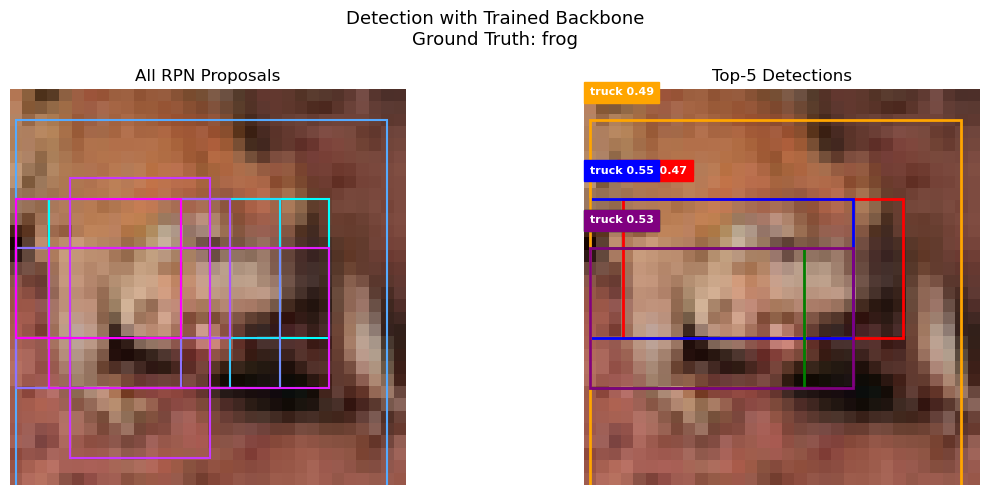

✅ Saved: detection_output.png


In [13]:
# Now run detection pipeline again with the trained backbone
# Feature maps will be semantically meaningful this time

backbone_trained = keras.models.load_model("backbone_trained.keras")

proposals_t, pred_classes_t, pred_scores_t, obj_scores_t = run_detection_pipeline(
    sample_img, backbone_trained, rpn, detection_head, anchors
)

visualize_detections(
    sample_img, proposals_t, pred_classes_t, pred_scores_t,
    obj_scores_t, CLASS_NAMES, top_n=5,
    title="Detection with Trained Backbone"
)



## Limitations of This Implementation

- RPN is not trained → proposals are not optimized.
- Detection head is not trained on bounding box labels.
- No **IoU (Intersection over Union)** calculation.
- No **mAP (Mean Average Precision)** evaluation.
- CIFAR-10 does not contain bounding box annotations.

This implementation focuses on understanding the architecture rather than achieving real detection performance.



## Evaluation Metrics (Conceptual)

In real object detection systems, the following metrics are used:

- **IoU (Intersection over Union)**: Measures overlap between predicted and ground truth boxes.
- **Precision & Recall**: Evaluate detection correctness.
- **mAP (Mean Average Precision)**: Standard metric for object detection performance.

These are not implemented here due to dataset and scope limitations.



## Conclusion

This notebook demonstrates a simplified implementation of a Faster R-CNN-style object detection pipeline.

### Key Learnings:
- The backbone network extracts meaningful feature representations.
- The RPN generates candidate object regions using anchors.
- ROI pooling standardizes region sizes for classification.
- The detection head predicts object classes and refines bounding boxes.

### Trade-offs and Observations:
- Without training the RPN and detection head, predictions are not accurate.
- The pipeline structure is correct but lacks optimization.
- Using CIFAR-10 limits the ability to perform real object detection.

### Real-World Perspective:
In production systems:
- RPN is trained jointly with the backbone.
- ROI Align replaces ROI Pooling for better accuracy.
- mAP is used for evaluation.
- Large datasets like COCO or Pascal VOC are used.

Overall, this implementation successfully demonstrates the architecture and workflow of Faster R-CNN, providing a strong foundation for further development into a full detection system.
